In [1]:
# Cell 1 — Install Libraries
!pip install requests beautifulsoup4 pandas matplotlib seaborn

In [3]:
# Cell 2 — Import Libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported!')

✅ All libraries imported!


In [4]:

url = 'http://books.toscrape.com'
response = requests.get(url)

print(f'Status Code : {response.status_code}')
if response.status_code == 200:
    print('✅ Successfully connected to website!')
else:
    print('❌ Connection failed. Check your internet.')

Status Code : 200
✅ Successfully connected to website!


In [5]:

url = 'http://books.toscrape.com'
soup = BeautifulSoup(requests.get(url).content, 'html.parser')

first_book = soup.find('article', class_='product_pod')
print('📄 HTML Structure of First Book:')
print(first_book.prettify())

📄 HTML Structure of First Book:
<article class="product_pod">
 <div class="image_container">
  <a href="catalogue/a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   £51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
  <form>
   <button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">
    Add to basket
   </button>
  </form>
 </div>
</article>



In [6]:

def convert_rating(word):
    rating_map = {
        'One'  : 1,
        'Two'  : 2,
        'Three': 3,
        'Four' : 4,
        'Five' : 5
    }
    return rating_map.get(word, 0)

print('✅ Rating converter ready!')
print(f"   Test: 'Four' → {convert_rating('Four')} stars")

✅ Rating converter ready!
   Test: 'Four' → 4 stars


In [7]:

def scrape_page(url):
    """Scrape all books from a single page"""
    response = requests.get(url)
    soup     = BeautifulSoup(response.content, 'html.parser')
    books    = soup.find_all('article', class_='product_pod')

    page_data = []
    for book in books:
        # Title
        title = book.find('h3').find('a')['title']

        # Price
        price = book.find('p', class_='price_color').text
        price = float(price.replace('£', '').replace('Â', '').strip())

        # Rating
        rating_word = book.find('p', class_='star-rating')['class'][1]
        rating      = convert_rating(rating_word)

        # Availability
        availability = book.find('p', class_='instock').text.strip()

        page_data.append({
            'Title'       : title,
            'Price (£)'   : price,
            'Rating'      : rating,
            'Availability': availability
        })

    return page_data

# Test on first page
test_data = scrape_page('http://books.toscrape.com')
print(f'✅ Scraped {len(test_data)} books from page 1')
pd.DataFrame(test_data).head()

✅ Scraped 20 books from page 1


,Title,Price (£),Rating,Availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock


In [8]:

BASE_URL  = 'http://books.toscrape.com/catalogue/page-{}.html'
all_books = []

print('🔄 Scraping all pages...')
print('-' * 40)

for page_num in range(1, 51):  # 50 pages total
    if page_num == 1:
        url = 'http://books.toscrape.com'
    else:
        url = BASE_URL.format(page_num)

    page_books = scrape_page(url)
    all_books.extend(page_books)

    if page_num % 10 == 0:
        print(f'✅ Page {page_num}/50 done — Total books so far: {len(all_books)}')

    time.sleep(0.3)

print('-' * 40)
print(f'🎉 Scraping complete! Total books: {len(all_books)}')

🔄 Scraping all pages...
----------------------------------------
✅ Page 10/50 done — Total books so far: 200
✅ Page 20/50 done — Total books so far: 400
✅ Page 30/50 done — Total books so far: 600
✅ Page 40/50 done — Total books so far: 800
✅ Page 50/50 done — Total books so far: 1000
----------------------------------------
🎉 Scraping complete! Total books: 1000


In [11]:

def scrape_categories():
    url      = 'http://books.toscrape.com'
    soup     = BeautifulSoup(requests.get(url).content, 'html.parser')
    cat_list = soup.find('ul', class_='nav-list').find('ul').find_all('li')

    categories = []
    for cat in cat_list:
        name    = cat.find('a').text.strip()
        cat_url = 'http://books.toscrape.com/' + cat.find('a')['href']
        categories.append({'Category': name, 'URL': cat_url})

    return categories

categories = scrape_categories()
cat_df     = pd.DataFrame(categories)
print(f'✅ Found {len(cat_df)} categories!')
cat_df.head(10)

✅ Found 50 categories!


,Category,URL
0,Travel,http://books.toscrape.com/catalogue/category/b...
1,Mystery,http://books.toscrape.com/catalogue/category/b...
2,Historical Fiction,http://books.toscrape.com/catalogue/category/b...
3,Sequential Art,http://books.toscrape.com/catalogue/category/b...
4,Classics,http://books.toscrape.com/catalogue/category/b...
5,Philosophy,http://books.toscrape.com/catalogue/category/b...
6,Romance,http://books.toscrape.com/catalogue/category/b...
7,Womens Fiction,http://books.toscrape.com/catalogue/category/b...
8,Fiction,http://books.toscrape.com/catalogue/category/b...
9,Childrens,http://books.toscrape.com/catalogue/category/b...


In [12]:

df = pd.DataFrame(all_books)

df['Price (£)'] = pd.to_numeric(df['Price (£)'], errors='coerce')
df['Rating']    = pd.to_numeric(df['Rating'],    errors='coerce')

df.to_csv('scraped_books.csv', index=False)

print('✅ Data saved to scraped_books.csv!')
print(f'\n📊 Dataset Info:')
print(f'   • Total Books      : {len(df)}')
print(f'   • Columns          : {list(df.columns)}')
print(f'   • Price Range      : £{df["Price (£)"].min()} — £{df["Price (£)"].max()}')
print(f'   • Average Price    : £{df["Price (£)"].mean():.2f}')
print(f'   • Average Rating   : {df["Rating"].mean():.1f} stars')
print()
df.head(10)

✅ Data saved to scraped_books.csv!

📊 Dataset Info:
   • Total Books      : 1000
   • Columns          : ['Title', 'Price (£)', 'Rating', 'Availability']
   • Price Range      : £10.0 — £59.99
   • Average Price    : £35.07
   • Average Rating   : 2.9 stars



,Title,Price (£),Rating,Availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock
5,The Requiem Red,22.65,1,In stock
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,In stock
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,In stock
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,In stock
9,The Black Maria,52.15,1,In stock


In [14]:

print('=' * 45)
print('       📋 DATASET OVERVIEW')
print('=' * 45)
print(f'\nShape         : {df.shape}')
print(f'\nData Types:')
print(df.dtypes)
print(f'\nMissing Values:')
print(df.isnull().sum())
print(f'\nBasic Statistics:')
df.describe()

       📋 DATASET OVERVIEW

Shape         : (1000, 4)

Data Types:
Title            object
Price (£)       float64
Rating            int64
Availability     object
dtype: object

Missing Values:
Title           0
Price (£)       0
Rating          0
Availability    0
dtype: int64

Basic Statistics:


,Price (£),Rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


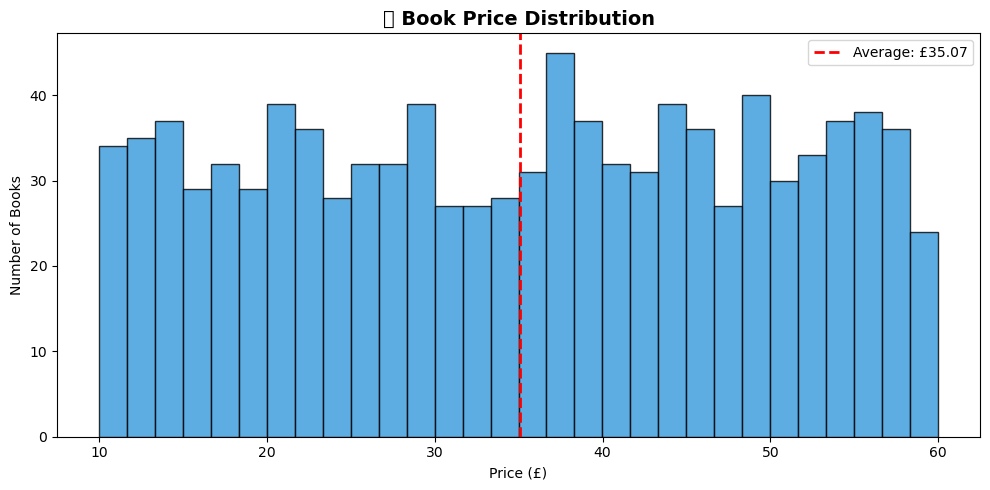

✅ Chart 1 saved!


In [15]:

plt.figure(figsize=(10, 5))

plt.hist(df['Price (£)'], bins=30, color='#3498db', edgecolor='black', alpha=0.8)
plt.axvline(df['Price (£)'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Average: £{df['Price (£)'].mean():.2f}")

plt.title('💰 Book Price Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.legend()
plt.tight_layout()
plt.savefig('ws_chart1_price_distribution.png', dpi=150)
plt.show()
print('✅ Chart 1 saved!')

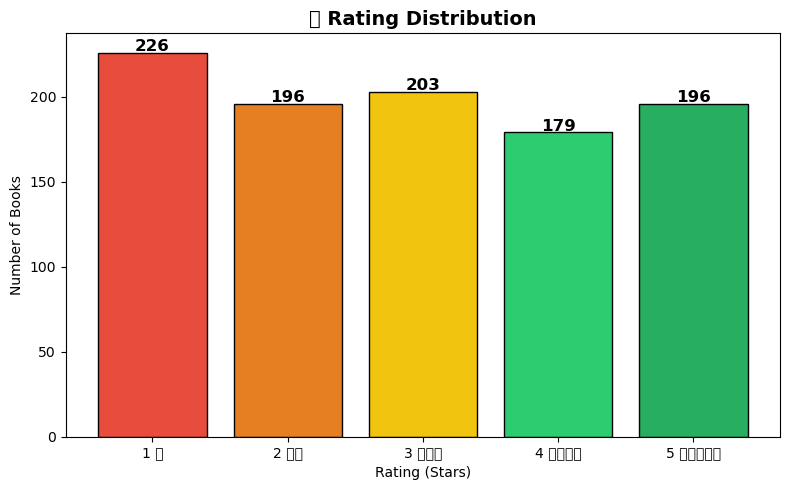

✅ Chart 2 saved!


In [16]:

plt.figure(figsize=(8, 5))

rating_counts = df['Rating'].value_counts().sort_index()
bars = plt.bar(rating_counts.index, rating_counts.values,
               color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
               edgecolor='black')

for bar, v in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 1,
             str(v), ha='center', fontweight='bold', fontsize=12)

plt.title('⭐ Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Books')
plt.xticks([1,2,3,4,5], ['1 ⭐','2 ⭐⭐','3 ⭐⭐⭐','4 ⭐⭐⭐⭐','5 ⭐⭐⭐⭐⭐'])
plt.tight_layout()
plt.savefig('ws_chart2_rating_distribution.png', dpi=150)
plt.show()
print('✅ Chart 2 saved!')

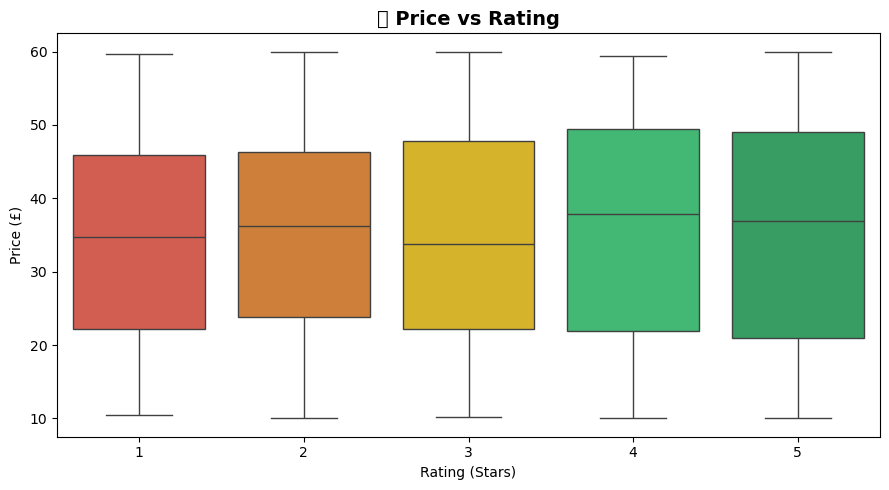

✅ Chart 3 saved!


In [17]:

plt.figure(figsize=(9, 5))

sns.boxplot(x='Rating', y='Price (£)', data=df,
            palette=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'])

plt.title('💰 Price vs Rating', fontsize=14, fontweight='bold')
plt.xlabel('Rating (Stars)')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.savefig('ws_chart3_price_vs_rating.png', dpi=150)
plt.show()
print('✅ Chart 3 saved!')

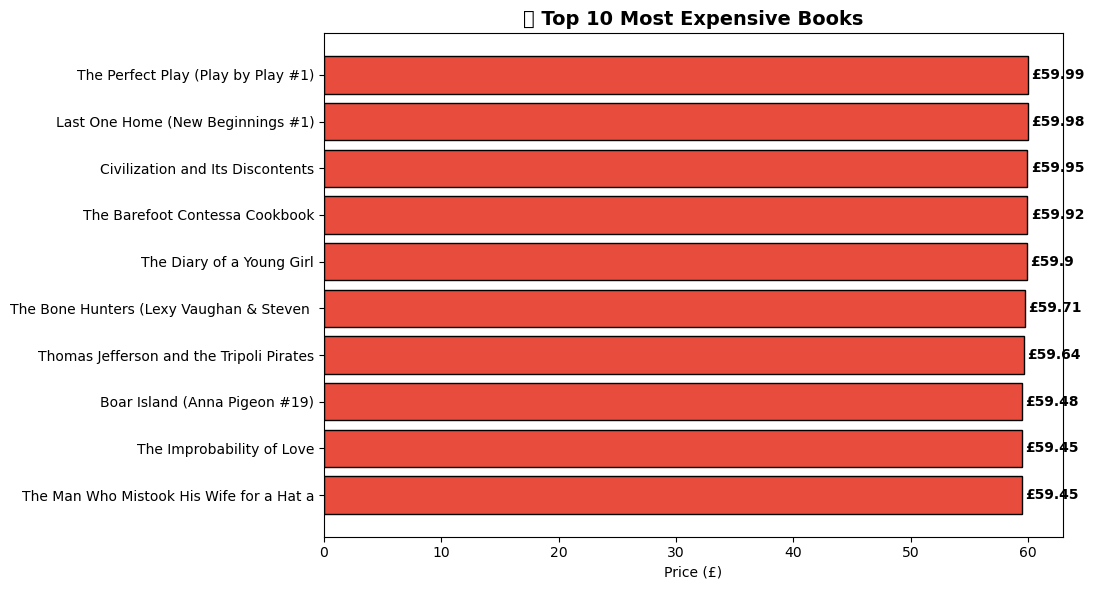

✅ Chart 4 saved!


In [18]:

top10_expensive = df.nlargest(10, 'Price (£)')

plt.figure(figsize=(11, 6))
bars = plt.barh(top10_expensive['Title'].str[:40],
                top10_expensive['Price (£)'],
                color='#e74c3c', edgecolor='black')

for bar, v in zip(bars, top10_expensive['Price (£)']):
    plt.text(v + 0.3, bar.get_y() + bar.get_height()/2,
             f'£{v}', va='center', fontweight='bold')

plt.title('💎 Top 10 Most Expensive Books', fontsize=14, fontweight='bold')
plt.xlabel('Price (£)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('ws_chart4_expensive_books.png', dpi=150)
plt.show()
print('✅ Chart 4 saved!')

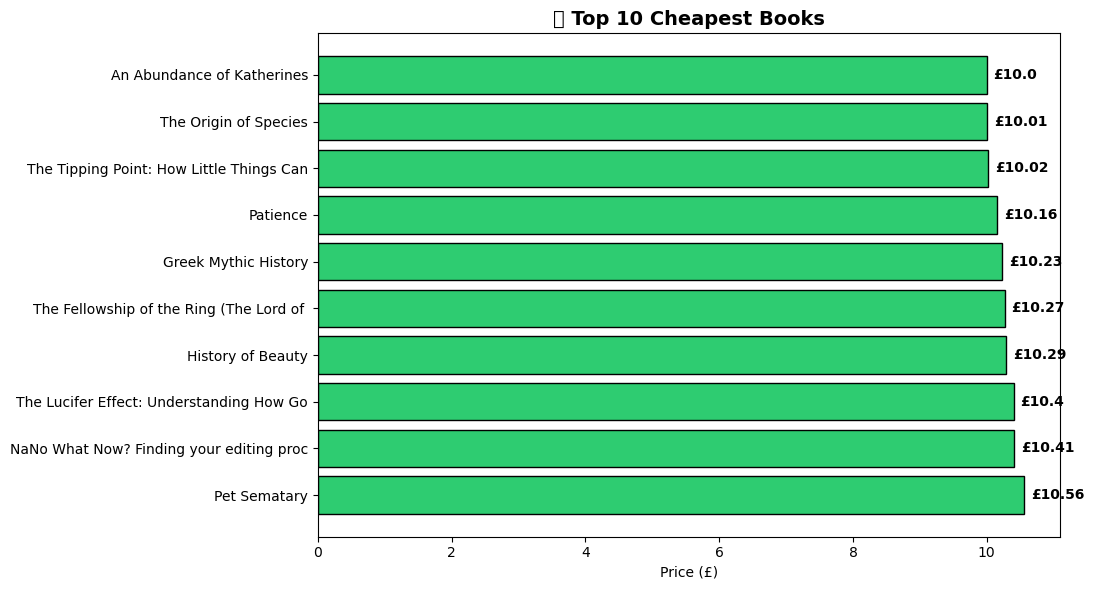

✅ Chart 5 saved!


In [19]:

top10_cheap = df.nsmallest(10, 'Price (£)')

plt.figure(figsize=(11, 6))
bars = plt.barh(top10_cheap['Title'].str[:40],
                top10_cheap['Price (£)'],
                color='#2ecc71', edgecolor='black')

for bar, v in zip(bars, top10_cheap['Price (£)']):
    plt.text(v + 0.1, bar.get_y() + bar.get_height()/2,
             f'£{v}', va='center', fontweight='bold')

plt.title('🏷️ Top 10 Cheapest Books', fontsize=14, fontweight='bold')
plt.xlabel('Price (£)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('ws_chart5_cheap_books.png', dpi=150)
plt.show()
print('✅ Chart 5 saved!')

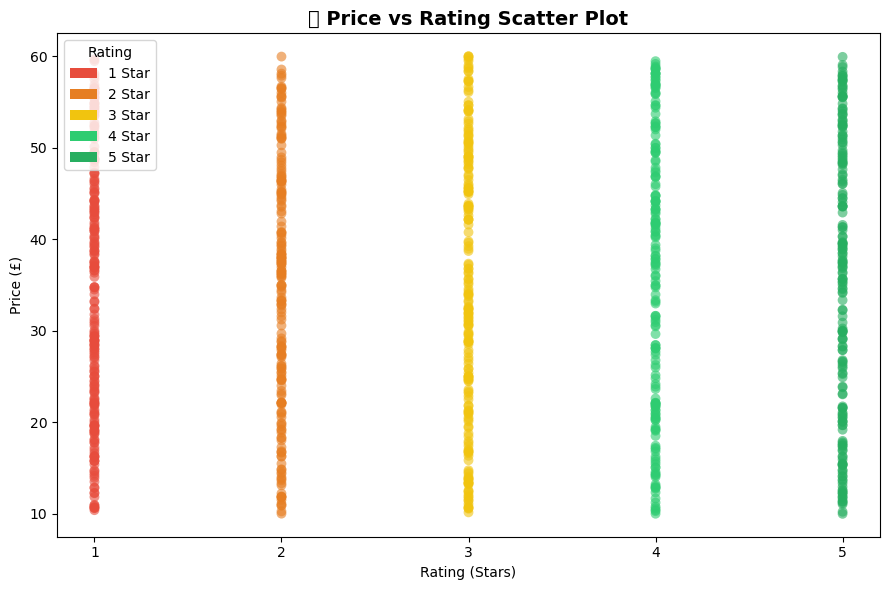

✅ Chart 6 saved!


In [20]:

plt.figure(figsize=(9, 6))

colors_map = {1:'#e74c3c', 2:'#e67e22', 3:'#f1c40f', 4:'#2ecc71', 5:'#27ae60'}
scatter_colors = df['Rating'].map(colors_map)

plt.scatter(df['Rating'], df['Price (£)'],
            c=scatter_colors, alpha=0.6, edgecolors='none', s=50)

plt.title('🔵 Price vs Rating Scatter Plot', fontsize=14, fontweight='bold')
plt.xlabel('Rating (Stars)')
plt.ylabel('Price (£)')
plt.xticks([1, 2, 3, 4, 5])

from matplotlib.patches import Patch
legend = [Patch(facecolor=colors_map[i], label=f'{i} Star') for i in range(1, 6)]
plt.legend(handles=legend, title='Rating')

plt.tight_layout()
plt.savefig('ws_chart6_scatter.png', dpi=150)
plt.show()
print('✅ Chart 6 saved!')

In [21]:

print('=' * 55)
print('   📚 WEB SCRAPING SUMMARY — BOOKS.TOSCRAPE.COM')
print('=' * 55)
print(f'\n🌐 Website Scraped  : books.toscrape.com')
print(f'📄 Total Pages      : 50')
print(f'📚 Total Books      : {len(df)}')
print(f'📁 Saved To         : scraped_books.csv')

print(f'\n💰 PRICE INSIGHTS:')
print(f'   • Cheapest Book    : £{df["Price (£)"].min()}')
print(f'   • Most Expensive   : £{df["Price (£)"].max()}')
print(f'   • Average Price    : £{df["Price (£)"].mean():.2f}')
print(f'   • Median Price     : £{df["Price (£)"].median():.2f}')

print(f'\n⭐ RATING INSIGHTS:')
for r in range(1, 6):
    count = len(df[df['Rating'] == r])
    pct   = count / len(df) * 100
    stars = '⭐' * r
    print(f'   • {stars:<10}: {count:>3} books ({pct:.1f}%)')

print('=' * 55)
print('✅ Task 1 Complete — CodeAlpha Internship')

   📚 WEB SCRAPING SUMMARY — BOOKS.TOSCRAPE.COM

🌐 Website Scraped  : books.toscrape.com
📄 Total Pages      : 50
📚 Total Books      : 1000
📁 Saved To         : scraped_books.csv

💰 PRICE INSIGHTS:
   • Cheapest Book    : £10.0
   • Most Expensive   : £59.99
   • Average Price    : £35.07
   • Median Price     : £35.98

⭐ RATING INSIGHTS:
   • ⭐         : 226 books (22.6%)
   • ⭐⭐        : 196 books (19.6%)
   • ⭐⭐⭐       : 203 books (20.3%)
   • ⭐⭐⭐⭐      : 179 books (17.9%)
   • ⭐⭐⭐⭐⭐     : 196 books (19.6%)
✅ Task 1 Complete — CodeAlpha Internship
